# 📊 Notebook 03 — Preprocesamiento, EDA y Preparación de Datos

**Tesis:** Modelo de Redes Neuronales para Predecir Consumo de Combustible Automotriz  
**Autor:** Eduardo Javier Oña Chiriboga — PUCE Ambato  

---

## 📋 Tabla de Contenidos

1. [Instalación de dependencias](#1)
2. [Detección de entorno y configuración de rutas](#2)
3. [Lectura robusta del dataset_crudo.csv](#3)
4. [Reporte de calidad y limpieza](#4)
5. [Agregación diaria y guardado de dataset_diario.csv](#5)
6. [Pivote a formato ancho y dataset_limpio.csv](#6)
7. [Tratamiento de outliers extremos](#7)
8. [Ingeniería de features → dataset_features.csv](#8)
9. [Análisis EDA y gráficas](#9)
10. [Resumen estadístico → resumen_eda.csv](#10)
11. [Escalado y creación de ventanas temporales](#11)
12. [División train/val/test y guardado de .npy y .pkl](#12)
13. [Verificación final](#13)

---
> **Salida de este notebook:** datasets procesados, arrays .npy y scalers .pkl en `/data/`  
> **Siguiente paso:** Notebook 04 — Entrenamiento y evaluación de arquitecturas

## 1. Instalación de dependencias <a id='1'></a>

In [19]:
import subprocess, sys

REQUERIDOS = [
    ('tensorflow', 'tensorflow'),
    ('scikit-learn', 'sklearn'),
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('seaborn', 'seaborn'),
    ('joblib', 'joblib'),
]

for pkg, imp in REQUERIDOS:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  Instalado: {pkg}')

print('✅ Dependencias verificadas')

✅ Dependencias verificadas


## 2. Detección de entorno y configuración de rutas <a id='2'></a>

In [20]:
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ────────────────────────────────────────────────────────
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

# ── Parámetros globales ──────────────────────────────────────────────────────
WINDOW_SIZE = 30
HORIZON     = 1
PRODUCTOS   = ['extra', 'super', 'diesel']

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15  (lo que queda)

# ── Detección de entorno ─────────────────────────────────────────────────────
def detectar_entorno():
    try:
        import google.colab
        EN_COLAB = True
    except ImportError:
        EN_COLAB = False

    if EN_COLAB:
        print('📍 Entorno: Google Colab')
        if not os.path.exists('/content/Redes_Neuronales_completo'):
            subprocess.run(
                ['git', 'clone',
                 'https://github.com/Javier-Eduardo/Redes_Neuronales_completo.git',
                 '/content/Redes_Neuronales_completo'],
                check=True
            )
        BASE = '/content/Redes_Neuronales_completo'
    else:
        print('📍 Entorno: Local (VS Code)')
        candidatos = [
            os.getcwd(),
            os.path.dirname(os.path.abspath('__file__')),
        ]
        BASE = None
        for c in candidatos:
            if os.path.exists(os.path.join(c, 'dataset_crudo.csv')):
                BASE = c
                break
        if BASE is None:
            raise FileNotFoundError(
                '❌ No se encontró dataset_crudo.csv en el directorio actual.\n'
                '   Abre VS Code en la CARPETA RAÍZ del proyecto.\n'
                '   La carpeta raíz debe contener: dataset_crudo.csv, 03_*.ipynb, etc.'
            )

    PATHS = {
        'base':      BASE,
        'data':      os.path.join(BASE, 'data'),
        'modelos':   os.path.join(BASE, 'modelos'),
        'graf_eval': os.path.join(BASE, 'graficos', 'evaluacion'),
        'graf_pred': os.path.join(BASE, 'graficos', 'predicciones'),
        'crudo':     os.path.join(BASE, 'dataset_crudo.csv'),
    }
    for k in ['data', 'modelos', 'graf_eval', 'graf_pred']:
        os.makedirs(PATHS[k], exist_ok=True)

    size_mb = os.path.getsize(PATHS['crudo']) / 1024 / 1024
    print(f'✅ dataset_crudo.csv encontrado: {size_mb:.1f} MB')
    print(f'✅ Carpetas listas: {list(PATHS.keys())}')
    return PATHS, EN_COLAB

PATHS, EN_COLAB = detectar_entorno()
print(f'\nBase: {PATHS["base"]}')
print(f'Data: {PATHS["data"]}')

📍 Entorno: Local (VS Code)
✅ dataset_crudo.csv encontrado: 18.7 MB
✅ Carpetas listas: ['base', 'data', 'modelos', 'graf_eval', 'graf_pred', 'crudo']

Base: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4
Data: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\data


## 3. Lectura robusta del dataset_crudo.csv <a id='3'></a>

In [21]:
# ── Lectura con detección de encoding ───────────────────────────────────────
def leer_csv_robusto(ruta):
    for enc in ['utf-8-sig', 'utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(ruta, encoding=enc, low_memory=False)
            print(f'✅ Encoding exitoso: {enc}')
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError('❌ No se pudo leer el archivo con ningún encoding estándar.')

df_raw = leer_csv_robusto(PATHS['crudo'])

# Normalizar nombres de columnas
df_raw.columns = [c.strip().replace('\ufeff', '').lower()
                    .replace(' ', '_').replace('.', '') for c in df_raw.columns]

print(f'\nColumnas detectadas: {df_raw.columns.tolist()}')
print(f'Total filas: {len(df_raw):,}')
print(f'\nPrimeras filas:')
display(df_raw.head(5))

✅ Encoding exitoso: utf-8-sig

Columnas detectadas: ['fecha', 'hora', 'product0', 'vol', 'año', 'mes']
Total filas: 466,139

Primeras filas:


,fecha,hora,product0,vol,año,mes
0,2022-02-23,04:39:35,DIESEL,0.038,2022,2
1,2022-02-23,08:58:02,DIESEL,39.475,2022,2
2,2022-02-23,09:09:58,DIESEL,7.894,2022,2
3,2022-02-23,09:43:34,DIESEL,21.324,2022,2
4,2022-02-23,09:48:04,DIESEL,7.894,2022,2


In [22]:
# ── Detección automática de columnas clave ───────────────────────────────────
def detectar_columna(df, palabras_clave, nombre_logico, requerida=True):
    for col in df.columns:
        for kw in palabras_clave:
            if kw in col:
                print(f'✅ Columna "{nombre_logico}" detectada: "{col}"')
                return col
    if requerida:
        raise ValueError(
            f'❌ No se encontró columna para "{nombre_logico}".\n'
            f'   Palabras buscadas: {palabras_clave}\n'
            f'   Columnas disponibles: {df.columns.tolist()}\n'
            f'   → Edita la variable "{nombre_logico.upper()}_COL" manualmente.'
        )
    print(f'⚠️  Columna "{nombre_logico}" no encontrada — se omite (opcional)')
    return None

FECHA_COL    = detectar_columna(df_raw, ['fecha', 'date', 'fec', 'time'], 'fecha')
PRODUCTO_COL = detectar_columna(df_raw, ['product', 'producto', 'tip', 'comb', 'nombre', 'desc'], 'producto')
VOLUMEN_COL  = detectar_columna(df_raw, ['vol', 'volumen', 'cantidad', 'cant', 'litro', 'galon', 'desp'], 'volumen')
HORA_COL     = detectar_columna(df_raw, ['hora', 'time', 'hh'], 'hora', requerida=False)
TRANS_COL    = detectar_columna(df_raw, ['trans', 'ticket', 'conteo'], 'transacciones', requerida=False)
IMPUTADO_COL = detectar_columna(df_raw, ['imput', 'parcial', 'estimad'], 'dato_imputado', requerida=False)

print(f'\nResumen de detección:')
print(f'  FECHA_COL    = {FECHA_COL}')
print(f'  PRODUCTO_COL = {PRODUCTO_COL}')
print(f'  VOLUMEN_COL  = {VOLUMEN_COL}')
print(f'  HORA_COL     = {HORA_COL}')
print(f'  TRANS_COL    = {TRANS_COL}')
print(f'  IMPUTADO_COL = {IMPUTADO_COL}')
print(f'\nValores únicos en "{PRODUCTO_COL}": {df_raw[PRODUCTO_COL].unique()}')

✅ Columna "fecha" detectada: "fecha"
✅ Columna "producto" detectada: "product0"
✅ Columna "volumen" detectada: "vol"
✅ Columna "hora" detectada: "hora"
⚠️  Columna "transacciones" no encontrada — se omite (opcional)
⚠️  Columna "dato_imputado" no encontrada — se omite (opcional)

Resumen de detección:
  FECHA_COL    = fecha
  PRODUCTO_COL = product0
  VOLUMEN_COL  = vol
  HORA_COL     = hora
  TRANS_COL    = None
  IMPUTADO_COL = None

Valores únicos en "product0": <StringArray>
['DIESEL', 'EXTRA', 'SUPER']
Length: 3, dtype: str


## 4. Reporte de calidad y limpieza <a id='4'></a>

In [23]:
# ── Parsear fecha ────────────────────────────────────────────────────────────
df = df_raw.copy()

# Parsear fecha — intentar varios formatos
try:
    df[FECHA_COL] = pd.to_datetime(df[FECHA_COL], format='%Y-%m-%d')
except Exception:
    try:
        df[FECHA_COL] = pd.to_datetime(df[FECHA_COL])
    except Exception as e:
        raise ValueError(f'❌ No se pudo parsear la columna fecha "{FECHA_COL}": {e}')

# Asegurar que la fecha sea solo fecha (sin hora)
df[FECHA_COL] = df[FECHA_COL].dt.normalize()

# ── Reporte de calidad ANTES de limpieza ─────────────────────────────────────
print('=== REPORTE DE CALIDAD DEL DATASET ===')
print(f'Total filas:               {len(df):,}')
print(f'\nNulos por columna:')
print(df[[FECHA_COL, PRODUCTO_COL, VOLUMEN_COL]].isnull().sum().to_string())
print(f'\nFilas con volumen nulo:     {df[VOLUMEN_COL].isnull().sum():,}')
print(f'Filas con volumen = 0:      {(df[VOLUMEN_COL] == 0).sum():,}')
print(f'Filas con volumen negativo: {(df[VOLUMEN_COL] < 0).sum():,}')
print(f'Filas con fecha nula:       {df[FECHA_COL].isnull().sum():,}')
print(f'Filas con producto nulo:    {df[PRODUCTO_COL].isnull().sum():,}')

n_antes = len(df)

# ── Eliminar duplicados exactos ───────────────────────────────────────────────
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'\nFilas eliminadas por duplicados exactos: {n_dup:,}')

# ── Eliminar nulos críticos ───────────────────────────────────────────────────
df = df.dropna(subset=[FECHA_COL, PRODUCTO_COL, VOLUMEN_COL])
print(f'\nFilas eliminadas por nulos críticos:   {n_antes - len(df):,}')

# ── Eliminar volúmenes inválidos ──────────────────────────────────────────────
n_pre = len(df)
df[VOLUMEN_COL] = pd.to_numeric(df[VOLUMEN_COL], errors='coerce')
df = df.dropna(subset=[VOLUMEN_COL])
df = df[df[VOLUMEN_COL] > 0]
print(f'Filas eliminadas por volumen <= 0:     {n_pre - len(df):,}')

# ── Normalizar nombres de productos ──────────────────────────────────────────
df[PRODUCTO_COL] = df[PRODUCTO_COL].astype(str).str.upper().str.strip()

# Mapeo flexible
mapa_productos = {}
for val in df[PRODUCTO_COL].unique():
    v = val.upper()
    if 'EXTRA' in v:
        mapa_productos[val] = 'EXTRA'
    elif 'SUPER' in v or 'SÚPER' in v or 'SUPER' in v:
        mapa_productos[val] = 'SUPER'
    elif 'DIESEL' in v or 'DIÉSEL' in v or 'DIESE' in v:
        mapa_productos[val] = 'DIESEL'
    else:
        print(f'⚠️  Producto no reconocido: "{val}" — será EXCLUIDO')

df[PRODUCTO_COL] = df[PRODUCTO_COL].map(mapa_productos)
df = df.dropna(subset=[PRODUCTO_COL])

print(f'\nProductos válidos: {sorted(df[PRODUCTO_COL].unique())}')
print(f'Total filas válidas: {len(df):,}')
print(f'Rango de fechas: {df[FECHA_COL].min().date()} → {df[FECHA_COL].max().date()}')

=== REPORTE DE CALIDAD DEL DATASET ===
Total filas:               466,139

Nulos por columna:
fecha       0
product0    0
vol         0

Filas con volumen nulo:     0
Filas con volumen = 0:      0
Filas con volumen negativo: 0
Filas con fecha nula:       0
Filas con producto nulo:    0

Filas eliminadas por duplicados exactos: 2

Filas eliminadas por nulos críticos:   2
Filas eliminadas por volumen <= 0:     0

Productos válidos: ['DIESEL', 'EXTRA', 'SUPER']
Total filas válidas: 466,137
Rango de fechas: 2022-02-23 → 2025-11-17


## 5. Agregación diaria y guardado de dataset_diario.csv <a id='5'></a>

In [24]:
# ── Detectar si el dataset ya está a granularidad diaria o es transaccional ──
n_total = len(df)
n_combos_fecha_prod = df.groupby([FECHA_COL, PRODUCTO_COL]).ngroups
n_dias = df[FECHA_COL].nunique()
ratio = n_total / n_combos_fecha_prod

print(f'Total filas:                    {n_total:,}')
print(f'Combos fecha+producto únicos:   {n_combos_fecha_prod:,}')
print(f'Días únicos:                    {n_dias:,}')
print(f'Ratio filas/combo:              {ratio:.1f}')

if ratio > 1.5:
    print('\n📌 Dataset TRANSACCIONAL detectado → se agrega a diario')
    IS_TRANSACTIONAL = True
else:
    print('\n📌 Dataset ya DIARIO → solo se pivota')
    IS_TRANSACTIONAL = False

# ── Agregar a diario ─────────────────────────────────────────────────────────
# Para el formato de salida siempre usamos agregación
# (si ya es diario, groupby+sum no cambia nada)

agg_dict = {VOLUMEN_COL: 'sum'}
if TRANS_COL:
    agg_dict[TRANS_COL] = 'sum'

df_daily_agg = df.groupby([FECHA_COL, PRODUCTO_COL], as_index=False).agg(agg_dict)

# Calcular ticket_promedio = volumen_total / transacciones (si hay datos)
if TRANS_COL:
    df_daily_agg['ticket_promedio'] = np.where(
        df_daily_agg[TRANS_COL] > 0,
        df_daily_agg[VOLUMEN_COL] / df_daily_agg[TRANS_COL],
        np.nan
    )
else:
    # Si el dataset es transaccional, contar filas como transacciones
    df_trans_count = df.groupby([FECHA_COL, PRODUCTO_COL]).size().reset_index(name='transacciones')
    df_daily_agg = df_daily_agg.merge(df_trans_count, on=[FECHA_COL, PRODUCTO_COL], how='left')
    df_daily_agg['ticket_promedio'] = (
        df_daily_agg[VOLUMEN_COL] / df_daily_agg['transacciones'].clip(lower=1)
    )

# Añadir columna dato_imputado = 0 (son datos reales)
if IMPUTADO_COL and IMPUTADO_COL in df.columns:
    df_imp = df.groupby([FECHA_COL, PRODUCTO_COL])[IMPUTADO_COL].max().reset_index()
    df_daily_agg = df_daily_agg.merge(df_imp, on=[FECHA_COL, PRODUCTO_COL], how='left')
    df_daily_agg = df_daily_agg.rename(columns={IMPUTADO_COL: 'dato_imputado'})
else:
    df_daily_agg['dato_imputado'] = 0

# Renombrar columnas al estándar
rename_dict = {
    FECHA_COL:    'fecha',
    PRODUCTO_COL: 'producto',
    VOLUMEN_COL:  'volumen_diario',
}
if TRANS_COL:
    rename_dict[TRANS_COL] = 'transacciones'

df_diario = df_daily_agg.rename(columns=rename_dict)
df_diario.sort_values(['fecha', 'producto'], inplace=True)

# Asegurar columnas del estándar
cols_std = ['fecha', 'producto', 'volumen_diario', 'transacciones', 'ticket_promedio', 'dato_imputado']
for col in cols_std:
    if col not in df_diario.columns:
        df_diario[col] = 0
df_diario = df_diario[cols_std]

df_diario.to_csv(os.path.join(PATHS['data'], 'dataset_diario.csv'), index=False)
print(f'\n✅ dataset_diario.csv guardado: {len(df_diario):,} filas')
print(f'   Productos: {sorted(df_diario["producto"].unique())}')
print(f'   Rango: {df_diario["fecha"].min().date()} → {df_diario["fecha"].max().date()}')
display(df_diario.head(9))

Total filas:                    466,137
Combos fecha+producto únicos:   4,075
Días únicos:                    1,364
Ratio filas/combo:              114.4

📌 Dataset TRANSACCIONAL detectado → se agrega a diario

✅ dataset_diario.csv guardado: 4,075 filas
   Productos: ['DIESEL', 'EXTRA', 'SUPER']
   Rango: 2022-02-23 → 2025-11-17


,fecha,producto,volumen_diario,transacciones,ticket_promedio,dato_imputado
0,2022-02-23,DIESEL,2566.1110,106,24.208594,0
1,2022-02-23,EXTRA,912.9055,269,3.393701,0
2,2022-02-23,SUPER,30.5545,7,4.364929,0
3,2022-02-24,DIESEL,3004.9580,141,21.311759,0
4,2022-02-24,EXTRA,1776.1400,464,3.827888,0
5,2022-02-24,SUPER,110.4920,21,5.261524,0
6,2022-02-25,DIESEL,2678.9340,141,18.999532,0
7,2022-02-25,EXTRA,1872.7920,483,3.877416,0
8,2022-02-25,SUPER,91.3550,15,6.090333,0


## 6. Pivote a formato ancho y dataset_limpio.csv <a id='6'></a>

In [25]:
# ── Pivotar a formato ancho ────────────────────────────────────────────────
df_wide = df_diario.pivot_table(
    index='fecha',
    columns='producto',
    values='volumen_diario',
    aggfunc='sum'
).reset_index()
df_wide.columns.name = None
df_wide.columns = [c.lower() for c in df_wide.columns]

print('Columnas después del pivot:', df_wide.columns.tolist())

# Verificar que existen las 3 columnas de producto
for p in PRODUCTOS:
    if p not in df_wide.columns:
        raise ValueError(
            f'❌ Columna "{p}" no encontrada después del pivot.\n'
            f'   Columnas disponibles: {df_wide.columns.tolist()}'
        )

# ── Crear índice diario COMPLETO (sin gaps) ───────────────────────────────
fecha_min = df_wide['fecha'].min()
fecha_max = df_wide['fecha'].max()
idx_completo = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
df_wide = df_wide.set_index('fecha').reindex(idx_completo).reset_index()
df_wide.rename(columns={'index': 'fecha'}, inplace=True)

# Reporte de NaN después del reindex
nans_por_col = df_wide[PRODUCTOS].isnull().sum()
print(f'\nDías totales en el índice: {len(df_wide)}')
print(f'NaN por columna después del reindex:')
print(nans_por_col.to_string())
print('  (NaN = días sin ventas registradas — se imputan con 0)')

# Imputar NaN con 0 (días cerrados)
df_wide[PRODUCTOS] = df_wide[PRODUCTOS].fillna(0)

# Verificar que no quedan NaN
assert df_wide[PRODUCTOS].isnull().sum().sum() == 0, \
    '❌ Aún quedan NaN después de la imputación con 0'

# Guardar dataset_limpio.csv
df_wide.to_csv(os.path.join(PATHS['data'], 'dataset_limpio.csv'), index=False)

print(f'\n✅ dataset_limpio.csv guardado: {len(df_wide)} días')
print(f'   Rango: {df_wide["fecha"].min().date()} → {df_wide["fecha"].max().date()}')
display(df_wide.describe())

Columnas después del pivot: ['fecha', 'diesel', 'extra', 'super']

Días totales en el índice: 1364
NaN por columna después del reindex:
extra      4
super     11
diesel     2
  (NaN = días sin ventas registradas — se imputan con 0)

✅ dataset_limpio.csv guardado: 1364 días
   Rango: 2022-02-23 → 2025-11-17


,fecha,diesel,extra,super
count,1364,1364.000000,1364.000000,1364.000000
mean,2024-01-05 12:00:00,1862.426517,951.981466,48.387760
min,2022-02-23 00:00:00,0.000000,0.000000,0.000000
25%,2023-01-29 18:00:00,1475.085250,655.337000,26.337000
50%,2024-01-05 12:00:00,1851.240500,837.612500,41.313000
75%,2024-12-11 06:00:00,2283.338000,1209.530000,62.547750
max,2025-11-17 00:00:00,4363.132000,3694.215000,797.841000
std,NaN,650.300794,390.461804,37.602644


## 7. Tratamiento de outliers extremos <a id='7'></a>

In [26]:
# ── Tratar outliers extremos (solo reportar y reemplazar >5*IQR) ───────────
# Para series temporales NO se eliminan — se reemplazan por la mediana

def tratar_outliers_temporales(df_in, col, factor=5.0):
    serie = df_in[col].copy()
    serie_ventas = serie[serie > 0]
    Q1 = serie_ventas.quantile(0.25)
    Q3 = serie_ventas.quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + factor * IQR
    mascara = (serie > limite_sup) & (serie > 0)
    n_outliers = mascara.sum()
    if n_outliers > 0:
        mediana = serie_ventas.median()
        serie[mascara] = mediana
        print(f'  ⚠️  {col}: {n_outliers} outliers extremos (>{limite_sup:.0f}) → reemplazados por mediana ({mediana:.1f})')
    else:
        print(f'  ✅ {col}: sin outliers extremos (límite: {limite_sup:.0f})')
    return serie

print('Tratamiento de outliers (factor = 5.0 × IQR):')
for p in PRODUCTOS:
    df_wide[p] = tratar_outliers_temporales(df_wide, p)

print('\n✅ Outliers tratados')

Tratamiento de outliers (factor = 5.0 × IQR):
  ✅ extra: sin outliers extremos (límite: 3978)
  ⚠️  super: 3 outliers extremos (>240) → reemplazados por mediana (41.6)
  ✅ diesel: sin outliers extremos (límite: 6312)

✅ Outliers tratados


## 8. Ingeniería de features → dataset_features.csv <a id='8'></a>

In [27]:
# ── Ingeniería de features ───────────────────────────────────────────────────
df_feat = df_wide.copy()

for p in PRODUCTOS:
    # Lags temporales
    df_feat[f'{p}_lag1']  = df_feat[p].shift(1)
    df_feat[f'{p}_lag7']  = df_feat[p].shift(7)
    df_feat[f'{p}_lag30'] = df_feat[p].shift(30)
    # Medias móviles
    df_feat[f'{p}_rolling7']  = df_feat[p].rolling(7,  min_periods=1).mean()
    df_feat[f'{p}_rolling30'] = df_feat[p].rolling(30, min_periods=1).mean()

# Features de calendario
df_feat['dia_semana']    = df_feat['fecha'].dt.dayofweek
df_feat['mes']           = df_feat['fecha'].dt.month
df_feat['es_fin_semana'] = (df_feat['fecha'].dt.dayofweek >= 5).astype(int)

# Rellenar NaN de lags con 0 (días iniciales sin historia)
df_feat = df_feat.fillna(0)

# Ordenar columnas según el estándar
cols_feat = (
    ['fecha'] + PRODUCTOS +
    [f'{p}_lag{l}' for p in PRODUCTOS for l in [1, 7, 30]] +
    [f'{p}_rolling{r}' for p in PRODUCTOS for r in [7, 30]] +
    ['dia_semana', 'mes', 'es_fin_semana']
)
df_feat = df_feat[cols_feat]

df_feat.to_csv(os.path.join(PATHS['data'], 'dataset_features.csv'), index=False)
print(f'✅ dataset_features.csv guardado: {len(df_feat)} filas × {len(df_feat.columns)} columnas')
print(f'   Columnas: {df_feat.columns.tolist()}')

✅ dataset_features.csv guardado: 1364 filas × 22 columnas
   Columnas: ['fecha', 'extra', 'super', 'diesel', 'extra_lag1', 'extra_lag7', 'extra_lag30', 'super_lag1', 'super_lag7', 'super_lag30', 'diesel_lag1', 'diesel_lag7', 'diesel_lag30', 'extra_rolling7', 'extra_rolling30', 'super_rolling7', 'super_rolling30', 'diesel_rolling7', 'diesel_rolling30', 'dia_semana', 'mes', 'es_fin_semana']


## 9. Análisis EDA y gráficas <a id='9'></a>

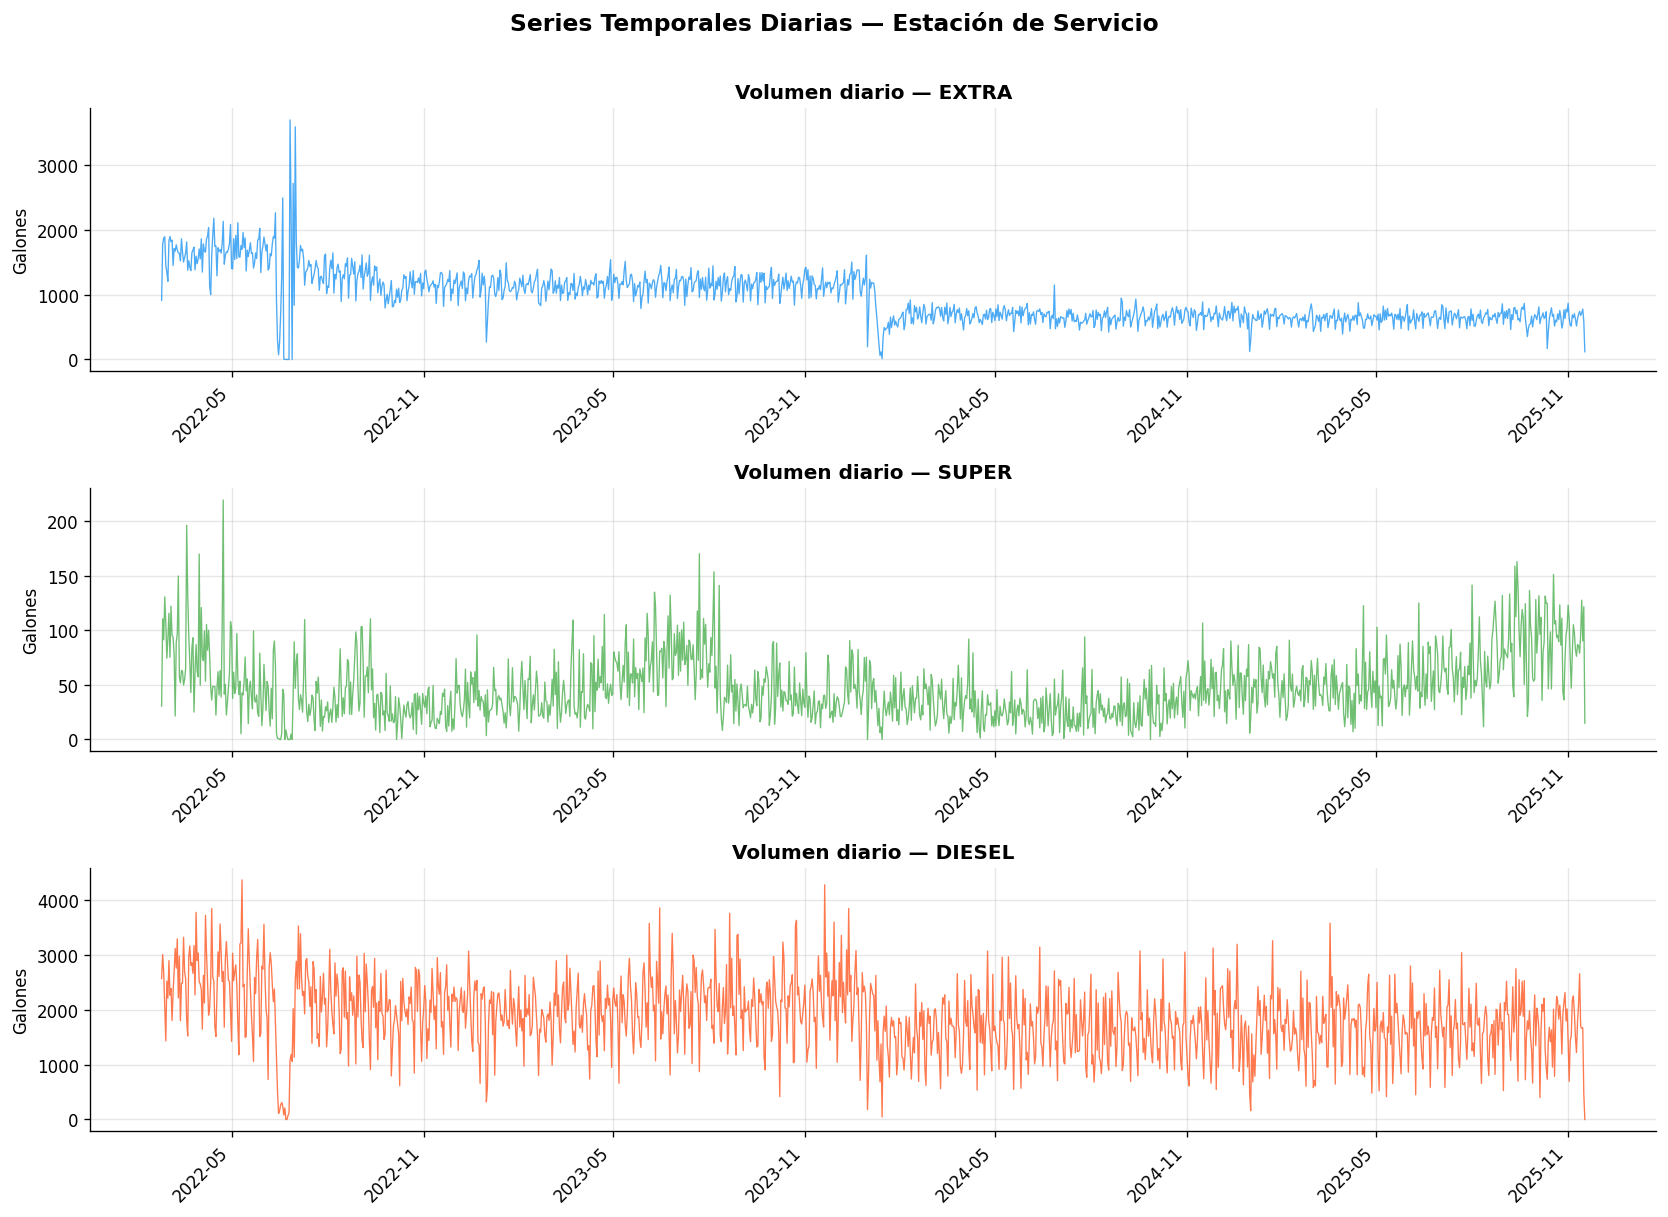

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\evaluacion\series_temporales.png


In [28]:
# ── Configuración global de matplotlib ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':     120,
    'figure.figsize': (14, 5),
    'axes.grid':      True,
    'grid.alpha':     0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
COLORES = {'extra': '#2196F3', 'super': '#4CAF50', 'diesel': '#FF5722'}

# ── Gráfica 1: Series temporales completas ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, p in zip(axes, PRODUCTOS):
    ax.plot(df_wide['fecha'], df_wide[p], color=COLORES[p], linewidth=0.8, alpha=0.8)
    ax.set_title(f'Volumen diario — {p.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Galones')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.suptitle('Series Temporales Diarias — Estación de Servicio', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
ruta_g1 = os.path.join(PATHS['graf_eval'], 'series_temporales.png')
plt.savefig(ruta_g1, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: {ruta_g1}')

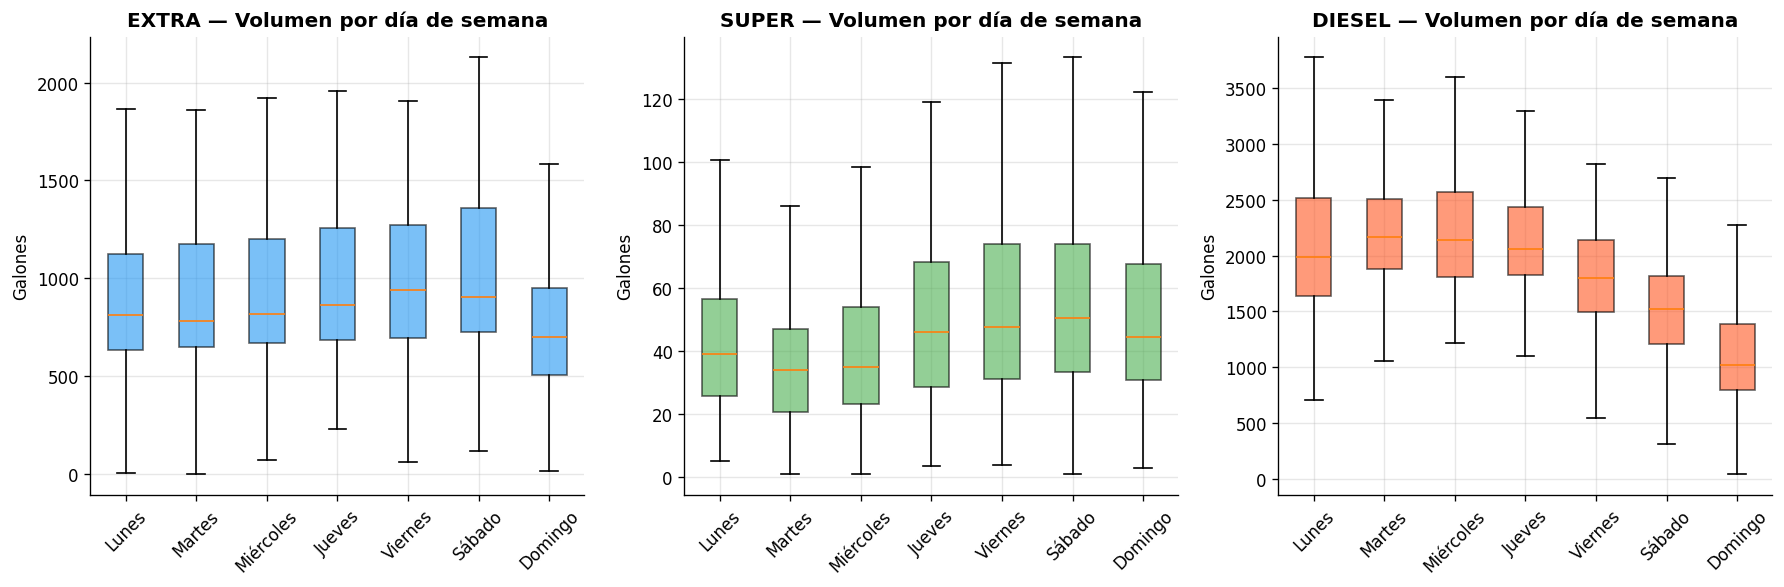

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\evaluacion\boxplot_dia_semana.png


In [29]:
# ── Gráfica 2: Distribuciones por día de la semana ────────────────────────
df_plot = df_wide.copy()
df_plot['dia_semana'] = df_plot['fecha'].dt.day_name()
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_esp   = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, p in zip(axes, PRODUCTOS):
    data_p = df_plot[df_plot[p] > 0]
    data_pivot = [data_p[data_p['dia_semana'] == d][p].values for d in dias_orden]
    bp = ax.boxplot(data_pivot, patch_artist=True, labels=dias_esp, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(COLORES[p])
        patch.set_alpha(0.6)
    ax.set_title(f'{p.upper()} — Volumen por día de semana', fontweight='bold')
    ax.set_ylabel('Galones')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
ruta_g2 = os.path.join(PATHS['graf_eval'], 'boxplot_dia_semana.png')
plt.savefig(ruta_g2, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: {ruta_g2}')

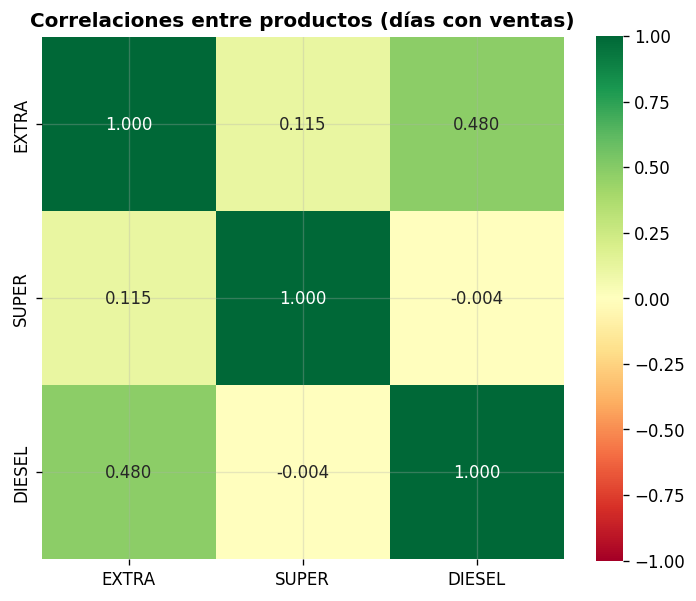

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\evaluacion\heatmap_correlaciones.png


In [30]:
# ── Gráfica 3: Heatmap de correlaciones ───────────────────────────────────
df_corr = df_wide[PRODUCTOS].copy()
df_corr_only_ventas = df_corr[(df_corr > 0).all(axis=1)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df_corr_only_ventas.corr(),
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=-1, vmax=1, square=True, ax=ax,
    xticklabels=[p.upper() for p in PRODUCTOS],
    yticklabels=[p.upper() for p in PRODUCTOS]
)
ax.set_title('Correlaciones entre productos (días con ventas)', fontweight='bold')
plt.tight_layout()
ruta_g3 = os.path.join(PATHS['graf_eval'], 'heatmap_correlaciones.png')
plt.savefig(ruta_g3, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: {ruta_g3}')

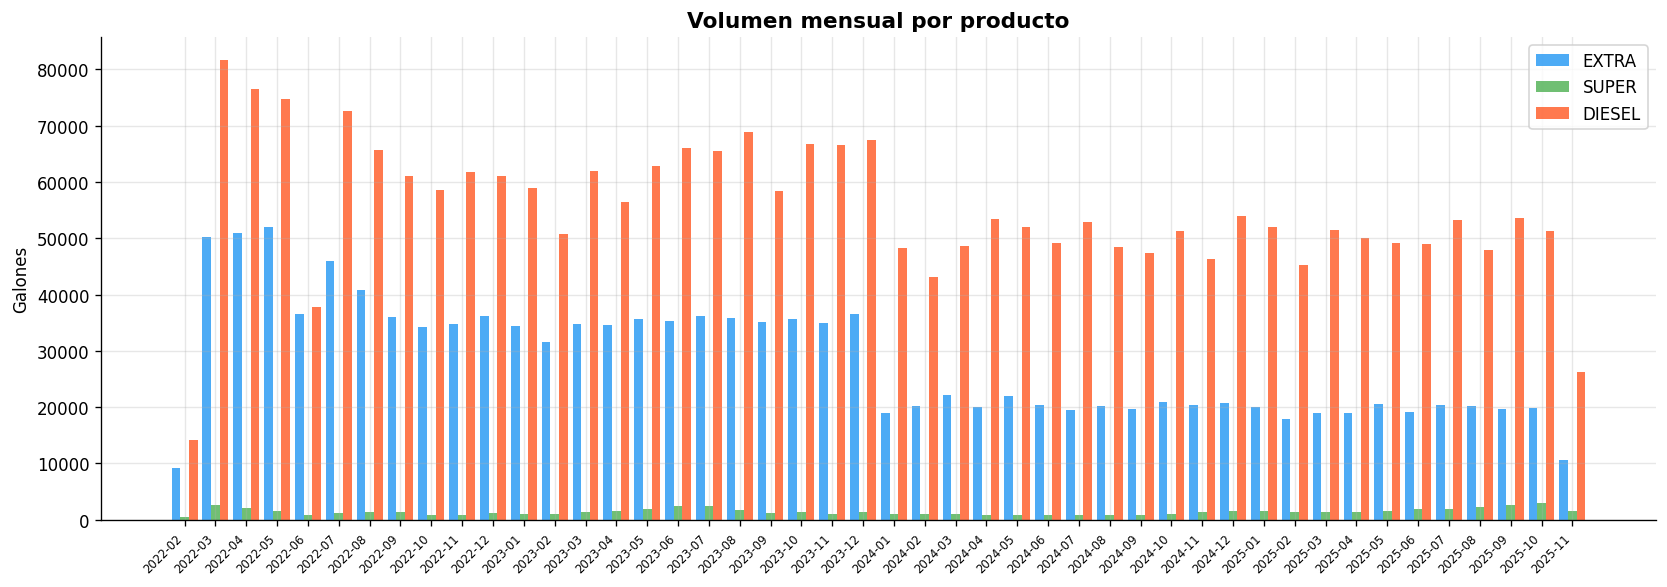

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\evaluacion\volumen_mensual.png


In [31]:
# ── Gráfica 4: Volumen mensual ─────────────────────────────────────────────
df_mensual = df_wide.copy()
df_mensual['año_mes'] = df_mensual['fecha'].dt.to_period('M')
df_mensual_sum = df_mensual.groupby('año_mes')[PRODUCTOS].sum().reset_index()
df_mensual_sum['periodo'] = df_mensual_sum['año_mes'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_mensual_sum))
width = 0.28
for i, p in enumerate(PRODUCTOS):
    ax.bar(x + i * width, df_mensual_sum[p], width, label=p.upper(), color=COLORES[p], alpha=0.8)
ax.set_xticks(x + width)
step = max(1, len(df_mensual_sum) // 18)
ax.set_xticklabels(df_mensual_sum['periodo'], rotation=45, ha='right', fontsize=7)
ax.set_title('Volumen mensual por producto', fontsize=13, fontweight='bold')
ax.set_ylabel('Galones')
ax.legend()
plt.tight_layout()
ruta_g4 = os.path.join(PATHS['graf_eval'], 'volumen_mensual.png')
plt.savefig(ruta_g4, bbox_inches='tight')
plt.show()
print(f'✅ Guardado: {ruta_g4}')

## 10. Resumen estadístico → resumen_eda.csv <a id='10'></a>

In [32]:
# ── Calcular estadísticas por producto ────────────────────────────────────
filas_eda = []
for p in PRODUCTOS:
    serie = df_wide[p]
    serie_ventas = serie[serie > 0]

    # Transacciones y ticket promedio desde df_diario
    df_p = df_diario[df_diario['producto'] == p.upper()]
    total_trans       = int(df_p['transacciones'].sum()) if 'transacciones' in df_p.columns else 0
    ticket_prom       = float(df_p['ticket_promedio'].mean()) if 'ticket_promedio' in df_p.columns else 0.0
    ticket_med        = float(df_p['ticket_promedio'].median()) if 'ticket_promedio' in df_p.columns else 0.0
    n_imputados       = int(df_p['dato_imputado'].sum()) if 'dato_imputado' in df_p.columns else 0
    pct_imputados     = round(n_imputados / max(len(serie), 1) * 100, 2)

    filas_eda.append({
        'producto':           p.upper(),
        'volumen_total':      round(float(serie_ventas.sum()), 3),
        'transacciones':      total_trans,
        'ticket_promedio':    round(ticket_prom, 3),
        'ticket_mediano':     round(ticket_med, 3),
        'dias_con_datos':     int((serie > 0).sum()),
        'pct_dias_imputados': pct_imputados,
        'vol_min_diario':     round(float(serie_ventas.min()), 3) if len(serie_ventas) > 0 else 0.0,
        'vol_max_diario':     round(float(serie_ventas.max()), 3) if len(serie_ventas) > 0 else 0.0,
        'vol_std_diario':     round(float(serie_ventas.std()), 3) if len(serie_ventas) > 1 else 0.0,
    })

df_eda = pd.DataFrame(filas_eda)
df_eda.to_csv(os.path.join(PATHS['data'], 'resumen_eda.csv'), index=False)
print('✅ resumen_eda.csv guardado')
display(df_eda)

✅ resumen_eda.csv guardado


,producto,volumen_total,transacciones,ticket_promedio,ticket_mediano,dias_con_datos,pct_dias_imputados,vol_min_diario,vol_max_diario,vol_std_diario
0,EXTRA,1298502.719,334470,3.879,3.867,1360,0.0,0.026,3694.215,387.600
1,SUPER,64641.247,12540,5.312,5.262,1353,0.0,0.862,219.482,29.160
2,DIESEL,2540349.769,119127,22.046,21.457,1362,0.0,0.124,4363.132,646.845


## 11. Escalado y creación de ventanas temporales <a id='11'></a>

In [33]:
from sklearn.preprocessing import MinMaxScaler

# ── Calcular los índices de corte ANTES de escalar (para evitar data leakage) ──
n_total   = len(df_wide)
n_train   = int(n_total * TRAIN_RATIO)
n_val     = int(n_total * VAL_RATIO)
n_test    = n_total - n_train - n_val

print(f'Días totales:   {n_total}')
print(f'Train:          {n_train} ({n_train/n_total*100:.1f}%)')
print(f'Validación:     {n_val}  ({n_val/n_total*100:.1f}%)')
print(f'Test:           {n_test}  ({n_test/n_total*100:.1f}%)')
print(f'\nRango Train:    {df_wide["fecha"].iloc[0].date()} → {df_wide["fecha"].iloc[n_train-1].date()}')
print(f'Rango Val:      {df_wide["fecha"].iloc[n_train].date()} → {df_wide["fecha"].iloc[n_train+n_val-1].date()}')
print(f'Rango Test:     {df_wide["fecha"].iloc[n_train+n_val].date()} → {df_wide["fecha"].iloc[-1].date()}')

# Guardar fechas de test para el notebook 05
fechas_test = df_wide['fecha'].values[n_train + n_val:]
np.save(os.path.join(PATHS['data'], 'fechas_test.npy'), fechas_test)
print(f'\n✅ fechas_test.npy guardado: {len(fechas_test)} fechas')

# ── Escalar por producto — fit SOLO sobre train ──────────────────────────
scalers = {}
datos_escalados = {}

for p in PRODUCTOS:
    scaler = MinMaxScaler(feature_range=(0, 1))
    valores = df_wide[p].values.reshape(-1, 1)
    # Fit SOLO sobre train para evitar data leakage
    scaler.fit(valores[:n_train])
    datos_escalados[p] = scaler.transform(valores).flatten()
    scalers[p] = scaler
    joblib.dump(scaler, os.path.join(PATHS['data'], f'scaler_{p}.pkl'))
    print(f'  ✅ scaler_{p}.pkl → rango: [{valores[:n_train].min():.1f}, {valores[:n_train].max():.1f}]')

# ── Escalar multivariante (los 3 productos juntos) ────────────────────────
from sklearn.preprocessing import MinMaxScaler
scaler_multi = MinMaxScaler(feature_range=(0, 1))
valores_multi = df_wide[PRODUCTOS].values
scaler_multi.fit(valores_multi[:n_train])
datos_escalados_multi = scaler_multi.transform(valores_multi)
joblib.dump(scaler_multi, os.path.join(PATHS['data'], 'scaler_multi.pkl'))
print(f'  ✅ scaler_multi.pkl guardado')

print('\n✅ Todos los scalers guardados')

Días totales:   1364
Train:          954 (69.9%)
Validación:     204  (15.0%)
Test:           206  (15.1%)

Rango Train:    2022-02-23 → 2024-10-03
Rango Val:      2024-10-04 → 2025-04-25
Rango Test:     2025-04-26 → 2025-11-17

✅ fechas_test.npy guardado: 206 fechas
  ✅ scaler_extra.pkl → rango: [0.0, 3694.2]
  ✅ scaler_super.pkl → rango: [0.0, 219.5]
  ✅ scaler_diesel.pkl → rango: [0.0, 4363.1]
  ✅ scaler_multi.pkl guardado

✅ Todos los scalers guardados


In [34]:
# ── Función para crear ventanas temporales ──────────────────────────────────
def crear_ventanas(data, window_size=30, horizon=1):
    """
    Crea pares (X, y) para modelo seq2one.
    data: array 1D o 2D (n_muestras, n_features)
    Retorna X: (n, window_size, n_features), y: (n, n_targets)
    """
    data = np.array(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    n_features = data.shape[1]
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size, :])
        y.append(data[i + window_size : i + window_size + horizon, :].flatten())
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ── Crear ventanas univariantes para cada producto ────────────────────────
for p in PRODUCTOS:
    data = datos_escalados[p]

    # Índices de corte DENTRO del array de ventanas
    # El array de ventanas tiene longitud: n_total - WINDOW_SIZE - HORIZON + 1
    X_all, y_all = crear_ventanas(data, WINDOW_SIZE, HORIZON)
    n_win = len(X_all)

    # Recalcular cortes en base al número de ventanas
    # Las ventanas del test empiezan donde los datos del test empiezan
    # índice en ventanas: n_total - WINDOW_SIZE - HORIZON + 1 ventanas totales
    # train: desde 0 hasta n_train - WINDOW_SIZE
    # val: desde n_train-WINDOW_SIZE hasta n_train+n_val-WINDOW_SIZE
    # test: el resto
    cut_train = n_train - WINDOW_SIZE
    cut_val   = n_train + n_val - WINDOW_SIZE

    X_tr = X_all[:cut_train]
    y_tr = y_all[:cut_train]
    X_v  = X_all[cut_train:cut_val]
    y_v  = y_all[cut_train:cut_val]
    X_te = X_all[cut_val:]
    y_te = y_all[cut_val:]

    print(f'\n{p.upper()} — Ventanas:')
    print(f'  Train:      X={X_tr.shape}, y={y_tr.shape}')
    print(f'  Val:        X={X_v.shape},  y={y_v.shape}')
    print(f'  Test:       X={X_te.shape}, y={y_te.shape}')

    # Verificaciones críticas
    assert not np.isnan(X_tr).any(), f'❌ X_train_{p} contiene NaN'
    assert not np.isnan(y_tr).any(), f'❌ y_train_{p} contiene NaN'
    assert X_tr.shape[1] == WINDOW_SIZE, f'❌ WINDOW_SIZE incorrecto: {X_tr.shape}'

    # Guardar
    np.save(os.path.join(PATHS['data'], f'X_train_{p}_nn.npy'), X_tr)
    np.save(os.path.join(PATHS['data'], f'X_val_{p}_nn.npy'),   X_v)
    np.save(os.path.join(PATHS['data'], f'X_test_{p}_nn.npy'),  X_te)
    np.save(os.path.join(PATHS['data'], f'y_train_{p}_nn.npy'), y_tr)
    np.save(os.path.join(PATHS['data'], f'y_val_{p}_nn.npy'),   y_v)
    np.save(os.path.join(PATHS['data'], f'y_test_{p}_nn.npy'),  y_te)

print('\n✅ Arrays univariantes guardados')


EXTRA — Ventanas:
  Train:      X=(924, 30, 1), y=(924, 1)
  Val:        X=(204, 30, 1),  y=(204, 1)
  Test:       X=(206, 30, 1), y=(206, 1)

SUPER — Ventanas:
  Train:      X=(924, 30, 1), y=(924, 1)
  Val:        X=(204, 30, 1),  y=(204, 1)
  Test:       X=(206, 30, 1), y=(206, 1)

DIESEL — Ventanas:
  Train:      X=(924, 30, 1), y=(924, 1)
  Val:        X=(204, 30, 1),  y=(204, 1)
  Test:       X=(206, 30, 1), y=(206, 1)

✅ Arrays univariantes guardados


## 12. División train/val/test multivariante y guardado <a id='12'></a>

In [35]:
# ── Arrays multivariantes (los 3 productos como features) ────────────────
X_multi, y_multi = crear_ventanas(datos_escalados_multi, WINDOW_SIZE, HORIZON)
n_win_multi = len(X_multi)

cut_train_m = n_train - WINDOW_SIZE
cut_val_m   = n_train + n_val - WINDOW_SIZE

X_tr_m = X_multi[:cut_train_m]
y_tr_m = y_multi[:cut_train_m]
X_v_m  = X_multi[cut_train_m:cut_val_m]
y_v_m  = y_multi[cut_train_m:cut_val_m]
X_te_m = X_multi[cut_val_m:]
y_te_m = y_multi[cut_val_m:]

print('MULTIVARIANTE — Ventanas:')
print(f'  Train:  X={X_tr_m.shape}, y={y_tr_m.shape}')
print(f'  Val:    X={X_v_m.shape},  y={y_v_m.shape}')
print(f'  Test:   X={X_te_m.shape}, y={y_te_m.shape}')

assert not np.isnan(X_tr_m).any(), '❌ X_train_multi contiene NaN'
assert not np.isnan(y_tr_m).any(), '❌ y_train_multi contiene NaN'

np.save(os.path.join(PATHS['data'], 'X_train_multi_nn.npy'), X_tr_m)
np.save(os.path.join(PATHS['data'], 'X_val_multi_nn.npy'),   X_v_m)
np.save(os.path.join(PATHS['data'], 'X_test_multi_nn.npy'),  X_te_m)
np.save(os.path.join(PATHS['data'], 'y_train_multi_nn.npy'), y_tr_m)
np.save(os.path.join(PATHS['data'], 'y_val_multi_nn.npy'),   y_v_m)
np.save(os.path.join(PATHS['data'], 'y_test_multi_nn.npy'),  y_te_m)

print('\n✅ Arrays multivariantes guardados')

MULTIVARIANTE — Ventanas:
  Train:  X=(924, 30, 3), y=(924, 3)
  Val:    X=(204, 30, 3),  y=(204, 3)
  Test:   X=(206, 30, 3), y=(206, 3)

✅ Arrays multivariantes guardados


## 13. Verificación final <a id='13'></a>

In [36]:
# ── Listar todos los archivos generados ──────────────────────────────────
print('=' * 60)
print('  VERIFICACIÓN FINAL — ARCHIVOS GENERADOS EN /data/')
print('=' * 60)

archivos_esperados = [
    'dataset_diario.csv',
    'dataset_limpio.csv',
    'dataset_features.csv',
    'resumen_eda.csv',
    'fechas_test.npy',
    'scaler_extra.pkl', 'scaler_super.pkl', 'scaler_diesel.pkl',
    'scaler_multi.pkl',
    'X_train_extra_nn.npy', 'X_val_extra_nn.npy', 'X_test_extra_nn.npy',
    'y_train_extra_nn.npy', 'y_val_extra_nn.npy', 'y_test_extra_nn.npy',
    'X_train_super_nn.npy', 'X_val_super_nn.npy', 'X_test_super_nn.npy',
    'y_train_super_nn.npy', 'y_val_super_nn.npy', 'y_test_super_nn.npy',
    'X_train_diesel_nn.npy', 'X_val_diesel_nn.npy', 'X_test_diesel_nn.npy',
    'y_train_diesel_nn.npy', 'y_val_diesel_nn.npy', 'y_test_diesel_nn.npy',
    'X_train_multi_nn.npy', 'X_val_multi_nn.npy', 'X_test_multi_nn.npy',
    'y_train_multi_nn.npy', 'y_val_multi_nn.npy', 'y_test_multi_nn.npy',
]

todos_ok = True
for fname in archivos_esperados:
    ruta = os.path.join(PATHS['data'], fname)
    if os.path.exists(ruta):
        size = os.path.getsize(ruta) / 1024
        print(f'  ✅ {fname:<40} {size:8.1f} KB')
    else:
        print(f'  ❌ {fname:<40} NO ENCONTRADO')
        todos_ok = False

print('\n' + '=' * 60)
if todos_ok:
    print('  ✅ TODOS LOS ARCHIVOS GENERADOS CORRECTAMENTE')
else:
    print('  ❌ FALTAN ARCHIVOS — REVISAR LAS CELDAS ANTERIORES')
print('=' * 60)
print('\n📌 Siguiente paso: ejecutar 04_entrenamiento_nn.ipynb')

  VERIFICACIÓN FINAL — ARCHIVOS GENERADOS EN /data/
  ✅ dataset_diario.csv                          198.6 KB
  ✅ dataset_limpio.csv                           54.3 KB
  ✅ dataset_features.csv                        313.8 KB
  ✅ resumen_eda.csv                               0.3 KB
  ✅ fechas_test.npy                               1.7 KB
  ✅ scaler_extra.pkl                              0.7 KB
  ✅ scaler_super.pkl                              0.7 KB
  ✅ scaler_diesel.pkl                             0.7 KB
  ✅ scaler_multi.pkl                              0.8 KB
  ✅ X_train_extra_nn.npy                        108.4 KB
  ✅ X_val_extra_nn.npy                           24.0 KB
  ✅ X_test_extra_nn.npy                          24.3 KB
  ✅ y_train_extra_nn.npy                          3.7 KB
  ✅ y_val_extra_nn.npy                            0.9 KB
  ✅ y_test_extra_nn.npy                           0.9 KB
  ✅ X_train_super_nn.npy                        108.4 KB
  ✅ X_val_super_nn.npy              